# Chromium PBMC Landscape + Clustergram + Enrich

This tutorial starts with a public 10x Genomics Chromium count matrix and follows
the Scanpy-to-Celldega workflow:

1. preprocess the cells, compute a UMAP, and find Leiden clusters with Scanpy,
2. organize the clusters with a **SetCollection**, retaining cell membership,
   expression signatures, fraction expressing, and ranked marker genes,
3. explore marker-ranked **Clustergram** views linked to a **Landscape** UMAP
   and **Enrich**, and
4. annotate clusters and genes interactively.

Data: [PBMCs from a Healthy Donor: Whole Transcriptome Analysis](https://www.10xgenomics.com/datasets/pbm-cs-from-a-healthy-donor-whole-transcriptome-analysis-1-1-standard-4-0-0),
provided by 10x Genomics under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).
The filtered matrix contains 6,574 cells. It is downloaded once and cached locally.

## Setup

Use Python 3.11 or 3.12 and Celldega 0.26.0 or later. Install the notebook
dependencies in the environment used by your Jupyter kernel:

```python
%pip install "celldega[scanpy]>=0.26.0" igraph ipykernel
```

The Landscape reads hosted expression files for this same sample, and Enrich
queries the public Enrichr service. Both need an internet connection. The saved
interactive widgets on this documentation page work without a running Python kernel.

In [1]:
from importlib.metadata import version
from pathlib import Path
import shutil
from urllib.request import Request, urlopen
import warnings

import numpy as np
import pandas as pd
import scanpy as sc

import celldega as dega


print(f"celldega {version('celldega')}")
print(f"scanpy {version('scanpy')}")
sc.settings.verbosity = 1

celldega 0.26.0
scanpy 1.11.5


## Download and read the 10x count matrix

This is the Cell Ranger 4.0.0 filtered gene-expression matrix from the dataset
above. The HDF5 file is about 15 MB. Downloads use a temporary file so an
interrupted transfer is not reused as a complete matrix.

In [2]:
DATASET_URL = (
    "https://cf.10xgenomics.com/samples/cell-vdj/4.0.0/Parent_SC5_PBMC/"
    "Parent_SC5_PBMC_filtered_feature_bc_matrix.h5"
)

# Reuse the repository's notebook data directory when running from a checkout;
# otherwise cache the download beside the notebook.
working_dir = Path.cwd().resolve()
project_root = next(
    (
        directory
        for directory in (working_dir, *working_dir.parents)
        if (directory / "pyproject.toml").is_file() and (directory / "notebooks").is_dir()
    ),
    None,
)
data_dir = (project_root / "notebooks" if project_root else working_dir) / "data"
data_dir = data_dir / "chromium_data" / "chromium_pbmc_healthy-donor"
data_dir.mkdir(parents=True, exist_ok=True)
counts_path = data_dir / "Parent_SC5_PBMC_filtered_feature_bc_matrix.h5"

if not counts_path.is_file():
    partial = counts_path.with_suffix(".h5.part")
    request = Request(DATASET_URL, headers={"User-Agent": "celldega-example-notebook"})
    print("Downloading the 10x PBMC matrix...")
    try:
        with urlopen(request, timeout=300) as response, partial.open("wb") as output:
            shutil.copyfileobj(response, output, length=1024 * 1024)
        partial.replace(counts_path)
    except Exception:
        partial.unlink(missing_ok=True)
        raise

with warnings.catch_warnings():
    # The 10x matrix repeats some gene symbols; make them unique below.
    warnings.filterwarnings("ignore", message="Variable names are not unique")
    adata = sc.read_10x_h5(counts_path, gex_only=True)
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 6574 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

## Quality control and Scanpy clustering

Calculate mitochondrial, ribosomal, and hemoglobin QC metrics; retain cells
with at least 100 detected genes and genes detected in at least three cells.
These minimal filters keep the original tutorial's cell selection. Inspect QC
metrics and choose appropriate thresholds when applying this workflow to your own data.

Keep raw counts in `adata.layers["counts"]`. Normalize and log-transform `X`
for PCA, neighbor finding, UMAP, and marker testing. Highly variable genes
drive PCA, but **all retained genes remain available** for signatures and markers.

In [3]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains(r"^HB(?!P)")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True)

sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()

print(f"Retained {adata.n_obs:,} cells and {adata.n_vars:,} genes")
adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe().round(2)

Retained 6,565 cells and 18,314 genes


,n_genes_by_counts,total_counts,pct_counts_mt
count,6565.00,6565.00,6565.00
mean,1555.94,5014.09,6.27
std,624.40,3251.18,4.78
min,102.00,506.00,0.00
25%,1229.00,3353.00,4.33
50%,1473.00,4470.00,5.31
75%,1744.00,5728.00,6.57
max,6042.00,47031.00,82.33


In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata, mask_var="highly_variable", svd_solver="arpack", random_state=0)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40, random_state=0)
sc.tl.umap(adata, random_state=0)
sc.tl.leiden(
    adata,
    flavor="igraph",
    directed=False,
    n_iterations=2,
    resolution=1.0,
    random_state=0,
    key_added="leiden",
)

Plotting the UMAP stores Scanpy's cluster palette in `adata.uns["leiden_colors"]`.
The Landscape, SetCollection, and Clustergram reuse this palette, so each
cluster has the same color throughout the tutorial.

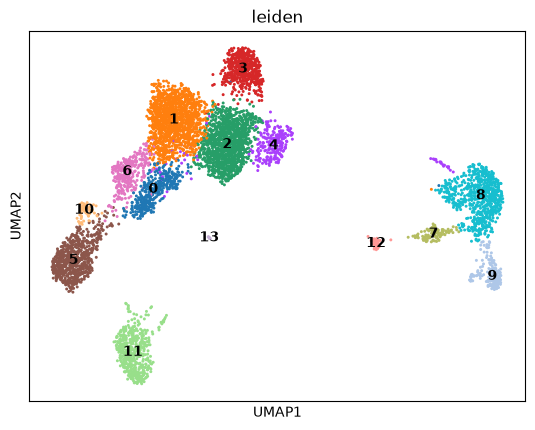

In [5]:
sc.pl.umap(adata, color="leiden", legend_loc="on data")

## SetCollection: signatures, fraction expressing, and marker genes

Each Leiden cluster becomes one set. The sparse `membership` modality records
which cells belong to it, and `setc.obs` records the cluster's cell count and color.

In [6]:
setc = dega.SetCollection(adata, set_col="leiden", name="leiden")
setc.obs[["leiden", "n_cells", "color"]]

,leiden,n_cells,color
leiden,,,
0,0,388,#1f77b4
1,1,1347,#ff7f0e
4,4,287,#aa40fc
3,3,590,#d62728
5,5,717,#8c564b
6,6,315,#e377c2
7,7,102,#b5bd61
2,2,1300,#279e68
8,8,704,#17becf


`calc_signature` attaches an `expression` modality with sets as observations
and genes as variables:

- `X`: summed raw counts per cluster, normalized to counts per million and
  log1p-transformed (`log1p_cpm` pseudobulk signatures).
- `layers["fraction_expressing"]`: the fraction of cells in each cluster with
  nonzero raw counts for each gene, used for dot size.
- `uns["rank_genes_groups"]`: Scanpy marker rankings computed on the **cell-level,
  log-normalized `adata.X`**, using a Wilcoxon test against the remaining cells.
- `var["leiden_marker"]`: each gene's highest-scoring cluster, used to color rows.

`layer="counts"` selects the aggregation and fraction-expressing source;
`rank_genes_groups_layer="X"` explicitly selects the normalized source for
marker testing. The method prints these sources. Marker rankings are retained
for every gene; they are exploratory cluster markers, not a comparison between donors.

In [7]:
setc.calc_signature(
    adata,
    modality_name="expression",
    layer="counts",
    aggregate="sum",
    normalization="log1p_cpm",
    fraction_expressing_layer="fraction_expressing",
    rank_genes_groups=True,
    rank_genes_groups_layer="X",
    rank_genes_groups_kwargs={"method": "wilcoxon", "tie_correct": True},
)
setc.mod["expression"]

calc_signature('expression'): sum of adata.layers['counts'] (normalization='log1p_cpm')
  layers['fraction_expressing']: fraction of cells with adata.layers['counts'] > 0.0
  uns['rank_genes_groups']: wilcoxon on adata.X, grouped by 'leiden'


AnnData object with n_obs × n_vars = 14 × 18314
    obs: 'leiden', 'n_cells', 'set_source', 'color'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene', 'leiden_marker', 'entity_type'
    uns: 'feature_type', 'aggregate', 'normalization', 'layer', 'expr_threshold', 'fraction_expressing_layer', 'rank_genes_groups', 'axis_entities'
    layers: 'fraction_expressing'

In [8]:
# Celldega stores the Scanpy results in a tidy, serializable column-wise form.
markers = pd.DataFrame(setc.mod["expression"].uns["rank_genes_groups"])
markers.loc[markers["rank"] < 3, ["group", "names", "scores", "logfoldchanges", "pvals_adj"]]

,group,names,scores,logfoldchanges,pvals_adj
0,0,CCL5,35.420982,4.864426,1.486653e-270
1,0,GZMK,33.622726,4.341601,7.151013e-244
2,0,CD8A,33.162933,3.802328,2.250873e-237
18314,1,IL7R,33.619164,2.286626,1.612469e-243
18315,1,LTB,33.150558,1.954962,5.090598e-237
18316,1,ITGB1,32.663368,2.362710,3.160020e-230
36628,10,SPTSSB,39.295662,7.293156,0.000000e+00
36629,10,KLRC1,31.671799,6.298415,3.479976e-216
36630,10,XCL1,25.369282,5.465434,3.361628e-138
54942,11,MS4A1,72.087128,8.787992,0.000000e+00


## Clustergram with marker-ranked views

The Matrix has **genes as rows** and **Leiden clusters as columns**. Its colors
show each gene's z-scored pseudobulk expression across clusters, while dot sizes
show the fraction of cells expressing it. Z-scoring changes only the Matrix;
the SetCollection retains the original signatures and fractions.

`cluster(view="rank_genes_groups", levels=...)` precomputes a view for each
requested number of **top markers per cluster**. Genes shared by multiple
clusters appear once, and both axes are hierarchically clustered again for each
view. The DIM slider switches between these views and the full gene matrix.
`rank_dim=3` starts at the top three markers per cluster.

In [9]:
marker_levels = [1, 2, 3, 5, 10, 25, 50, 75]

mat = dega.clust.Matrix(
    collection=setc,
    color_by="expression",
    size_by_layer="fraction_expressing",
    col_attr=["leiden"],
    row_attr=["leiden_marker"],
)
mat.norm("row", by="zscore")
mat.cluster(view="rank_genes_groups", levels=marker_levels)

for view in mat.views:
    print(f"{view['level']:>3} markers/cluster -> {view['n_rows']} genes")
print(f"all -> {mat.data.shape[0]:,} genes")

cgm = dega.viz.Clustergram(
    matrix=mat,
    width=450,
    height=500,
    viz_mode="dotplot",
    manual_col_cat="cell_type",
    manual_row_cat="info",
    rank_dim=3,
)

  1 markers/cluster -> 14 genes
  2 markers/cluster -> 27 genes
  3 markers/cluster -> 40 genes
  5 markers/cluster -> 67 genes
 10 markers/cluster -> 131 genes
 25 markers/cluster -> 312 genes
 50 markers/cluster -> 581 genes
 75 markers/cluster -> 836 genes
all -> 18,314 genes


## Landscape: view the same cells in UMAP space

Chromium cells have no tissue coordinates, so the Landscape displays the UMAP
computed above. It takes cell labels, colors, and the embedding from the **same
`adata`** used to build the SetCollection. The hosted LandscapeFiles supply
per-gene counts for this PBMC sample; they do not supply the newly computed clusters.

The signature records that columns are cells grouped by `leiden`, allowing a
Clustergram column click to select the matching cells in the Landscape.

In [10]:
base_url = "https://raw.githubusercontent.com/broadinstitute/chromium_pbmc_healthy-donor/main"

meta_cluster = setc.obs[["color"]].copy()
meta_cluster["count"] = setc.obs["n_cells"]
landscape = dega.viz.Landscape(
    technology="Chromium",
    base_url=base_url,
    adata=adata,
    meta_cluster=meta_cluster,
    cell_attr=["leiden"],
    cluster_attr="leiden",
    # Chromium UMAPs do not need a tissue-image coordinate transform.
    transform=np.eye(3),
    height=600,
    ini_zoom=-4.5,
    ini_x=4000,
    ini_y=5000,
)

## Linked Landscape, Clustergram, and Enrich

- Move the **DIM slider** to change the number of markers per cluster, or select
  **all** to show every retained gene.
- Click a **cluster column label** to highlight its cells in the UMAP and send
  its highest-valued genes in the current view to Enrich. This selection uses
  the displayed z-scores; the DIM views use the Scanpy marker rankings.
- Click a **gene row label** to show its expression in the UMAP without replacing
  the current enrichment gene set.
- Select a **gene dendrogram group** or crop rows to send that gene set to Enrich.
- Use Enrich's library selector to explore cell-type markers or biological
  processes. Select a term to highlight its genes in the Clustergram; click a
  gene in Enrich to focus it in both visualizations.
- Use the **ROW / COL** category controls and annotate selected genes or clusters
  with the manual `info` and `cell_type` categories.

Enrich starts with an empty gene list. Selections submit gene symbols to the
public [Enrichr](https://maayanlab.cloud/Enrichr/) API. The widgets link in the
browser, including in this saved documentation page.

In [11]:
linked_widgets = dega.viz.spatial_clustergram(
    landscape,
    cgm,
    enrich=True,
    enrich_kwargs={"inst_lib": "CellMarker_2024"},
)

# Keep every panel readable; wrap onto another row in narrower windows.
linked_widgets.layout.flex_flow = "row wrap"
for panel in linked_widgets.children:
    panel.layout.flex = "0 0 auto"

In [12]:
linked_widgets

## Continue in Python and save the analysis

In a live notebook the DIM slider is two-way, and manual annotations sync back
to Python:

```python
cgm.rank_dim = 10  # each cluster's top 10 markers
cgm.rank_dim = 0   # all genes

cgm.col_manual_df         # cluster -> cell_type
cgm.row_manual_df         # gene -> info
cgm.col_manual_colors_df  # cell_type -> color

cgm.col_manual_df.to_parquet(data_dir / "pbmc_cluster_annotations.parquet")
cgm.row_manual_df.to_parquet(data_dir / "pbmc_gene_annotations.parquet")

adata.write_h5ad(data_dir / "pbmc_scanpy.h5ad")
setc.write(data_dir / "pbmc_sets.h5mu")
```

The SetCollection saves membership, signatures, fractions, and marker rankings.
Widget annotations are saved separately in the Parquet files above. Reload the
collection and construct a Matrix with marker views without rerunning Scanpy:

```python
reloaded = dega.SetCollection.read(data_dir / "pbmc_sets.h5mu")
reloaded_mat = dega.clust.Matrix(
    collection=reloaded,
    color_by="expression",
    size_by_layer="fraction_expressing",
    col_attr=["leiden"],
    row_attr=["leiden_marker"],
)
reloaded_mat.norm("row", by="zscore")
reloaded_mat.cluster(view="rank_genes_groups", levels=marker_levels)
```

## Generate LandscapeFiles for your own Chromium data

The hosted files above keep this example interactive on the documentation site.
For another dataset, generate matching files from your own `adata` (including
its raw `counts` layer), then use a local server while running Jupyter on your machine:

```python
path_dega_files = Path("data/landscape_files/my_chromium_sample")
dega.pre.make_chromium_from_anndata(adata, path_dega_files)
port = dega.viz.get_local_server()
base_url = f"http://localhost:{port}/{path_dega_files.as_posix()}"
```

Use that `base_url` when constructing the Landscape. A local URL works only
while its server is running; to publish an interactive page, host the generated
files at a public HTTPS URL and save the widgets with that URL instead.